# Geometric Basket Asian Pricing: Closed Form and Validation

This notebook focuses on the geometric basket Asian option under correlated Black-Scholes dynamics.

It contains only the steps needed to:
1. simulate correlated risk-factor paths,
2. compute prices with the scalar and vectorized closed-form implementations,
3. validate discounted cash-flow consistency against the analytic time-zero price.

In [69]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "CODE" / "PaperCode"))

from factor_simulation import RiskFactorSimulator

import option_formulas

## Basket Setup and Simulated Paths

We set a multi-asset Black-Scholes model on a fixing grid $\{t_0,\dots,t_n\}$ and simulate paths in RNN layout `(simulations, time, assets)`.

Notation used below:
- $m$: number of assets,
- $n$: number of time steps,
- $S_{t_i}^j$: asset $j$ value at fixing time $t_i$,
- $\rho_{hk}$: instantaneous correlation between assets $h$ and $k$.

In [77]:
num_risk_factors = 3
initial_spot_values = [100.0, 60.0, 140.0]
drift_array = [0.03, 0.03, 0.03]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0,5,21)
num_sims = 1000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)

paths = simulator.simulate_paths(500)

## Check: scalar vs vectorized basket geometric Asian

This cell compares the scalar and vectorized implementations using the RNN-style path layout `(simulations, time, assets)`.


### Closed-Form Derivation (From Mondragon)

We price

$$V_T = \left(\left(\prod_{i=1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}-1\right)^+.$$

At date $t_v$:

$$V_{t_v}=E\left[\left(\left(\prod_{i=1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}-1\right)^+e^{-r(t_n-t_v)}\Big|\mathcal{F}_{t_v}\right].$$

Split known and future fixings:

$$V_{t_v}=E\left[\left(\left(\prod_{i=1}^{v}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}\left(\prod_{i=v+1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}-1\right)^+e^{-r(t_n-t_v)}\Big|\mathcal{F}_{t_v}\right].$$

Under correlated Black-Scholes,

$$r^j_{t_v,t_i}=\left(r-\frac{\sigma_j^2}{2}\right)(t_i-t_v)+\sigma_j\left(W_{t_i}^j-W_{t_v}^j\right),$$

and

$$\exp\left(\frac{1}{nm}\sum_{i=v+1}^{n}\sum_{j=1}^{m}r^j_{t_v,t_i}\right)\stackrel{d}{=}\exp\left(\mu+\sqrt{V}\phi\right),\quad \phi\sim N(0,1).$$

with

$$\mu=\frac{1}{nm}\sum_{i=v+1}^{n}\sum_{j=1}^{m}\left(r-\frac{\sigma_j^2}{2}\right)(t_i-t_v),$$

$$V=\frac{1}{n^2m^2}\sum_{h=1}^{m}\sum_{k=1}^{m}\sum_{i=v+1}^{n}\sum_{j=v+1}^{n}\sigma_h\sigma_k\rho_{hk}(\min(t_i,t_j)-t_v).$$

So the value is Black with strike $K=1$, maturity $T=t_n-t_v$, volatility $\hat\sigma=\sqrt{V/(t_n-t_v)}$, and forward

$$F=\left(\prod_{i=1}^{v}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}\left(\prod_{j=1}^{m}\left(\frac{S_{t_v}^j}{S_{t_0}^j}\right)^{n-v}\right)^{\frac{1}{nm}}\exp\left(\mu+\frac{V}{2}\right).$$

In [81]:
from option_formulas import basket_geom_asian, basket_geom_asian_vectorized
import torch


init_time_array = torch.as_tensor(time_steps, dtype=torch.float64)
n_assets = int(num_risk_factors)
n_times = len(init_time_array)

# Simulation output is RNN-style: (simulations, time, assets).
price_history = torch.as_tensor(paths, dtype=torch.float64)


risk_free_rate_t = torch.as_tensor(0.03, dtype=torch.float64)
volatility_t = torch.as_tensor(volatility_array, dtype=torch.float64)
correl_t = torch.as_tensor(corr_matrix, dtype=torch.float64)

vec_full = basket_geom_asian_vectorized(
    init_time_array=init_time_array,
    risk_free_rate=risk_free_rate_t,
    num_assets=n_assets,
    assets_vol=volatility_t,
    assets_correl=correl_t,
    price_history=price_history,
    IsCall=True,
)

# Compare only non-terminal dates to avoid scalar maturity edge-case.
vec_values = vec_full[:, :-1, :]

# Force identical dimensions: (simulations, time-1, 1)
scalar_values = torch.empty_like(vec_values)
for sim_index in range(price_history.shape[0]):
    for value_date_index in range(n_times - 1):
        scalar_values[sim_index, value_date_index, 0] = basket_geom_asian(
            init_time_array=init_time_array,
            value_date_index=value_date_index,
            risk_free_rate=risk_free_rate_t,
            num_assets=n_assets,
            assets_vol=volatility_t,
            assets_correl=correl_t,
            price_history=price_history[sim_index].T,
            IsCall=True,
        )

abs_diff = torch.abs(vec_values - scalar_values)

print(f"paths shape:        {tuple(price_history.shape)}")
print(f"vectorized shape:   {tuple(vec_values.shape)}")
print(f"scalar shape:       {tuple(scalar_values.shape)}")
print(f"max abs diff:       {abs_diff.max().item():.3e}")
print(f"mean abs diff:      {abs_diff.mean().item():.3e}")
assert torch.allclose(vec_values, scalar_values, rtol=1e-10, atol=1e-10)


paths shape:        (500, 21, 3)
vectorized shape:   (500, 20, 1)
scalar shape:       (500, 20, 1)
max abs diff:       7.216e-16
mean abs diff:      1.375e-17


## Check: discounted cash-flow stream

This cell checks that the realized cash-flow generator returns an RNN-style stream and that its Monte Carlo average is consistent with the analytic time-zero price.


### Why This Cash-Flow Check Matters

The discounted cash-flow representation should be fully consistent with the closed-form valuation:

1. Shape check: output must be `(simulations, time, 1)`.
2. Timing check: cash flow must be zero before maturity.
3. Pricing check: mean terminal discounted payoff should match the analytic $t_0$ price up to Monte Carlo sampling error.

This is a numerical validation that the implementation and valuation convention are aligned.

cashflows shape:       (500, 21, 1)
non-terminal abs sum:  0.000e+00
MC discounted payoff:  0.0588628776
analytic t0 price:     0.0627522690
abs diff:              3.889e-03
MC standard error:     4.221e-03
95% MC CI:             [0.0505894541, 0.0671363012]
analytic inside CI:    True


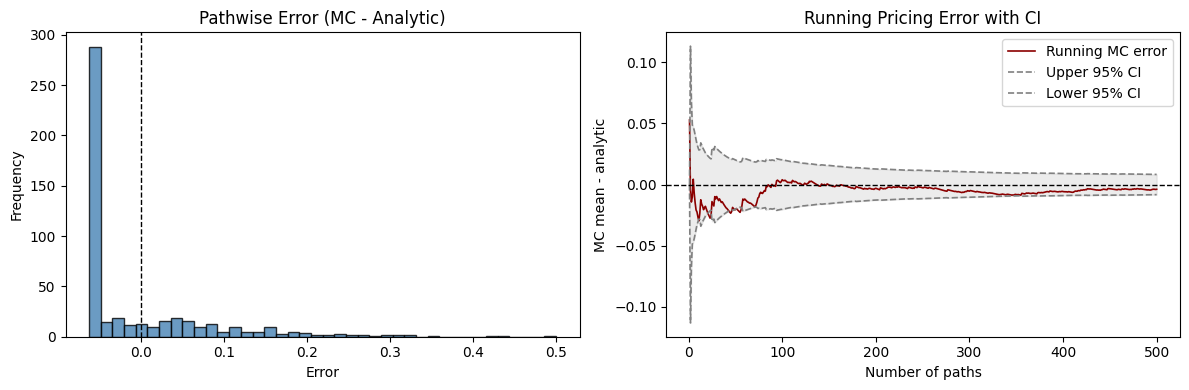

chart saved to: /Users/lolillosky/PHD_Projects/PHD_CVA/NOTEBOOKS/PaperNotebooks/mc_vs_analytic_error.png


In [92]:
from cashflows import basket_geom_asian_cashflows
from IPython.display import display
from pathlib import Path


cashflows = basket_geom_asian_cashflows(
    init_time_array=init_time_array,
    risk_free_rate=risk_free_rate_t,
    num_assets=n_assets,
    price_history=price_history,
    IsCall=True,
)

terminal_discounted = cashflows[:, -1, 0]
analytic_t0 = vec_values[:, 0, 0].mean()
mc_t0 = terminal_discounted.mean()
abs_diff = torch.abs(mc_t0 - analytic_t0)
std_error = terminal_discounted.std(unbiased=True) / torch.sqrt(
    torch.as_tensor(cashflows.shape[0], dtype=torch.float64)
)
confidence_level = 0.95
z_score = torch.as_tensor(1.959963984540054, dtype=torch.float64)
ci_low = mc_t0 - z_score * std_error
ci_high = mc_t0 + z_score * std_error
analytic_in_ci = (ci_low <= analytic_t0) & (analytic_t0 <= ci_high)

print(f"cashflows shape:       {tuple(cashflows.shape)}")
print(f"non-terminal abs sum:  {cashflows[:, :-1, :].abs().sum().item():.3e}")
print(f"MC discounted payoff:  {mc_t0.item():.10f}")
print(f"analytic t0 price:     {analytic_t0.item():.10f}")
print(f"abs diff:              {abs_diff.item():.3e}")
print(f"MC standard error:     {std_error.item():.3e}")
print(f"{confidence_level:.0%} MC CI:             [{ci_low.item():.10f}, {ci_high.item():.10f}]")
print(f"analytic inside CI:    {bool(analytic_in_ci)}")

# Plot analytical vs MC errors.
pathwise_error = (terminal_discounted - analytic_t0).detach().cpu().numpy()
running_n = np.arange(1, pathwise_error.size + 1)
running_mc = np.cumsum(terminal_discounted.detach().cpu().numpy()) / running_n
running_error = running_mc - analytic_t0.detach().cpu().item()

# Running confidence bounds for the MC error (normal approximation).
running_std = np.array([
    terminal_discounted[:k].detach().cpu().numpy().std(ddof=1) if k > 1 else terminal_discounted[0].detach().cpu().numpy() * 0.0
    for k in running_n
], dtype=float)
running_se = running_std / np.sqrt(running_n)
running_ci_upper = z_score.item() * running_se
running_ci_lower = -z_score.item() * running_se

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pathwise_error, bins=40, color="steelblue", alpha=0.8, edgecolor="black")
axes[0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Pathwise Error (MC - Analytic)")
axes[0].set_xlabel("Error")
axes[0].set_ylabel("Frequency")

axes[1].plot(running_n, running_error, color="darkred", linewidth=1.2, label="Running MC error")
axes[1].plot(running_n, running_ci_upper, color="gray", linestyle="--", linewidth=1.2, label="Upper 95% CI")
axes[1].plot(running_n, running_ci_lower, color="gray", linestyle="--", linewidth=1.2, label="Lower 95% CI")
axes[1].fill_between(running_n, running_ci_lower, running_ci_upper, color="gray", alpha=0.15)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Running Pricing Error with CI")
axes[1].set_xlabel("Number of paths")
axes[1].set_ylabel("MC mean - analytic")
axes[1].legend(loc="upper right")

plt.tight_layout()
display(fig)

output_png = Path.cwd() / "mc_vs_analytic_error.png"
fig.savefig(output_png, dpi=160, bbox_inches="tight")
print(f"chart saved to: {output_png}")

plt.close(fig)

assert cashflows.shape == (price_history.shape[0], price_history.shape[1], 1)
assert torch.allclose(cashflows[:, :-1, :], torch.zeros_like(cashflows[:, :-1, :]))
assert abs_diff < 4.0 * std_error
assert analytic_in_ci
